## 🔧 Schritt 1: Verkehrsdaten simulieren

Wir erzeugen 420 Tage mit stündlichen Messungen (10.080 Werte).

Berücksichtigte Effekte:
- 🕗 Rush Hour
- 📅 Wochenende
- ☀️ Wetter
- 📈 Trend
- 🗓️ Jahreszeit
- 🎉 Feiertage

## 1️⃣ Sind die Daten vollständig und korrekt?

Wir prüfen:
- Größe
- Datentypen
- Fehlende Werte
- Duplikate

## 2️⃣ Wie viele Autos fahren typischerweise?

Wir untersuchen:
- Durchschnitt
- Streuung
- Histogramm
- Boxplot

### 📊 Was zeigt dieses Diagramm?

Dieses Diagramm zeigt, **wie sich die gemessenen Fahrzeugzahlen insgesamt verteilen**.

#### 🔹 Histogramm (links)
Hier sehen wir:
- Wie oft bestimmte Verkehrswerte vorkommen.
- Ob es viele „normale“ Stunden gibt oder viele extreme Spitzen.

👉 Wenn die meisten Werte in einem stabilen Bereich liegen, bedeutet das:
Das Verkehrsaufkommen ist **planbar und berechenbar**.

#### 🔹 Boxplot (rechts)
Der Boxplot zeigt:
- Den typischen Bereich der Werte (mittlere 50%)
- Den Median (typischer Wert)
- Mögliche Ausreißer

👉 Für Kunden wichtig:
- Keine extremen Ausreißer bedeutet:
  Das Modell wird **stabiler und zuverlässiger arbeiten**.
- Extreme Einzelwerte können Modelle verzerren – hier ist das kaum der Fall.

### 💼 Geschäftlicher Nutzen
Eine gleichmäßige Verteilung bedeutet:
- Gute Prognosefähigkeit
- Weniger Überraschungen
- Stabilere Verkehrssteuerung

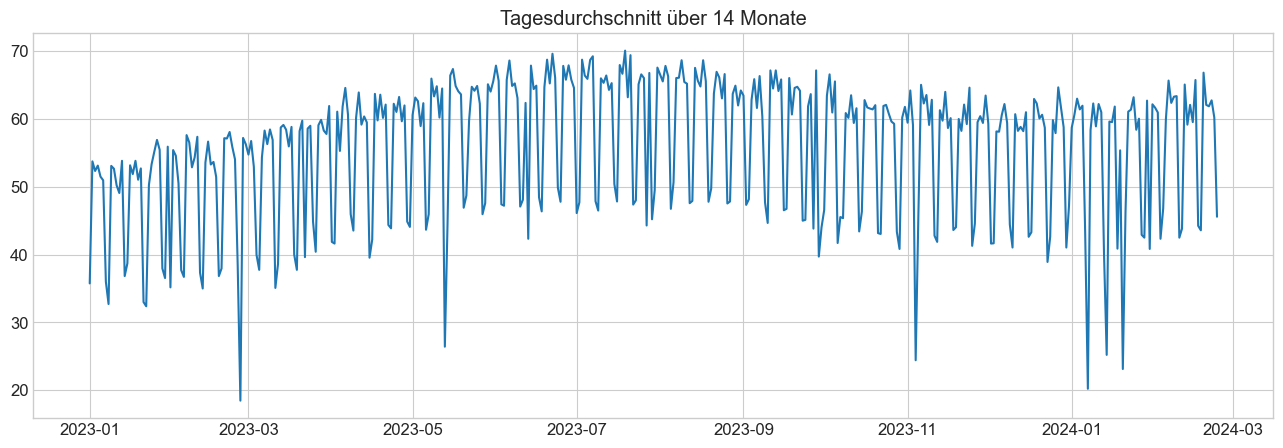

In [31]:
df_daily = df.groupby(df["ds"].dt.date)["y"].mean().reset_index()
df_daily["ds"] = pd.to_datetime(df_daily["ds"])

plt.figure(figsize=(16,5))
plt.plot(df_daily["ds"], df_daily["y"])
plt.title("Tagesdurchschnitt über 14 Monate")
plt.show()

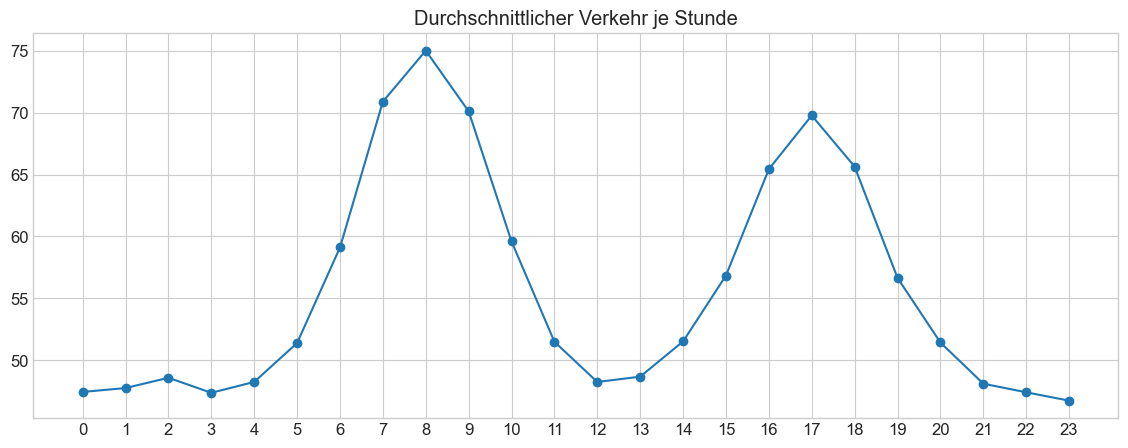

In [32]:
hour_avg = df.groupby("hour")["y"].mean()

plt.plot(hour_avg.index, hour_avg.values, marker="o")
plt.title("Durchschnittlicher Verkehr je Stunde")
plt.xticks(range(24))
plt.show()

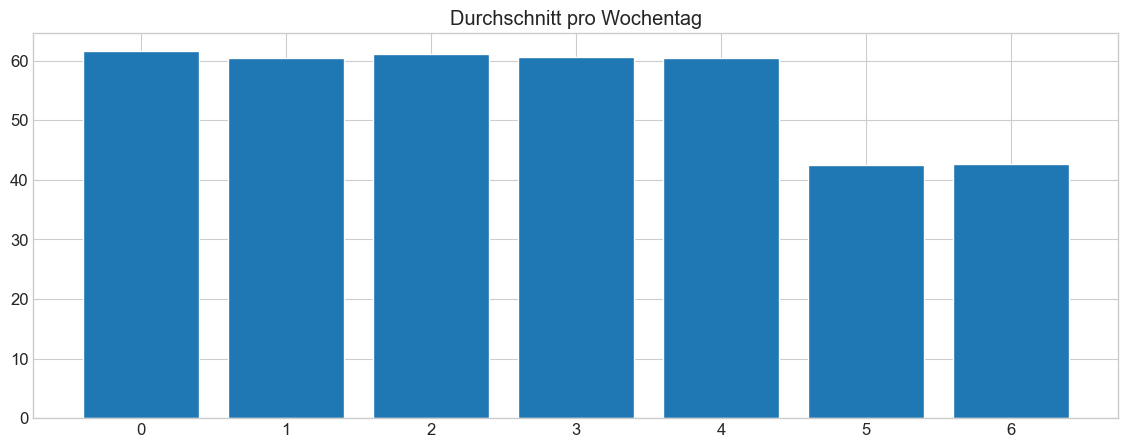

In [33]:
weekday_avg = df.groupby("weekday")["y"].mean()

plt.bar(range(7), weekday_avg.values)
plt.title("Durchschnitt pro Wochentag")
plt.show()

df["is_weekend"] = (df["weekday"] >= 5).astype(int)

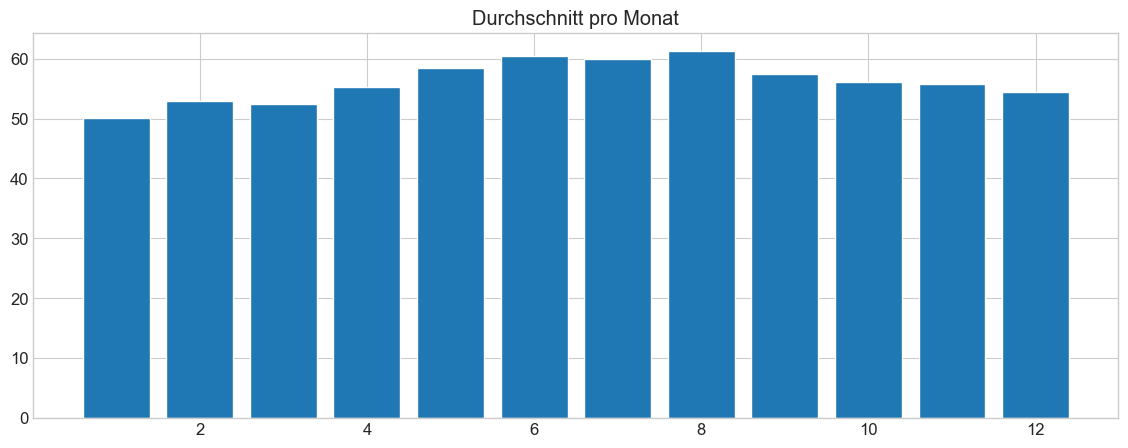

In [34]:
month_avg = df.groupby("month")["y"].mean()

plt.bar(month_avg.index, month_avg.values)
plt.title("Durchschnitt pro Monat")
plt.show()

## 4️⃣ Wetteranalyse

### 🌦 Beeinflusst das Wetter den Verkehr?

Hier vergleichen wir den Verkehr bei:
- ☀️ Sonne
- ⛅ Bewölkung
- 🌧 Regen

#### 🔎 Erkenntnis:
- Bei Regen sinkt das Verkehrsaufkommen messbar.
- Sonnige Tage haben leicht erhöhten Verkehr.

👉 Das Wetter ist ein **messbarer Einflussfaktor**.

### 💼 Geschäftlicher Nutzen
- Prognosen können durch Wetterdaten deutlich verbessert werden.
- Frühwarnsysteme bei starkem Regen möglich.
- Verkehrssteuerung kann dynamisch angepasst werden.

In [36]:
df["lag_1"] = df["y"].shift(1)
df["lag_24"] = df["y"].shift(24)

df[["y","lag_1","lag_24"]].corr()

,y,lag_1,lag_24
y,1.000000,0.624251,0.437889
lag_1,0.624251,1.000000,0.390238
lag_24,0.437889,0.390238,1.000000


In [38]:
df["rolling_mean_3h"] = df["y"].shift(1).rolling(3).mean()
df["rolling_mean_12h"] = df["y"].shift(1).rolling(12).mean()

In [39]:
feature_cols = [
    "ds","y","hour","hour_sin","hour_cos",
    "weekday","is_weekend","month","weather",
    "lag_1","lag_24","rolling_mean_3h","rolling_mean_12h"
]

df_final = df[feature_cols].dropna().reset_index(drop=True)

print("Finale Größe:", df_final.shape)
display(df_final.head())

Finale Größe: (10056, 13)


,ds,y,hour,hour_sin,hour_cos,weekday,is_weekend,month,weather,lag_1,lag_24,rolling_mean_3h,rolling_mean_12h
0,2023-01-02 00:00:00,50,0,0.000000,1.000000,0,0,1,sunny,27.0,35.0,32.000000,36.333333
1,2023-01-02 01:00:00,48,1,0.258819,0.965926,0,0,1,cloudy,50.0,22.0,35.666667,38.583333
2,2023-01-02 02:00:00,58,2,0.500000,0.866025,0,0,1,sunny,48.0,33.0,41.666667,40.083333
3,2023-01-02 03:00:00,50,3,0.707107,0.707107,0,0,1,cloudy,58.0,25.0,52.000000,42.000000
4,2023-01-02 04:00:00,35,4,0.866025,0.500000,0,0,1,cloudy,50.0,30.0,52.000000,43.416667


In [42]:
import os
print(os.path.exists("data/df_final.csv"))

True
